In [160]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
import copy
import seaborn as sns
import tensorflow as tf
from sklearn.linear_model import LinearRegression

In [161]:
dataset_cols = ["bike_count", "hour", "temp", "humidity", "wind", "visibility", "dew_pt_temp", "radiation", "rain", "snow", "functional"]
df = pd.read_csv("SeoulBikeData.csv", encoding="unicode_escape").drop(["Date", "Holiday", "Seasons"], axis=1)

In [162]:
df.columns = dataset_cols

In [163]:
df.head()
df["functional"] = (df["functional"] == "Yes").astype(int)
df = df[df["hour"] == 12]
df = df.drop(["hour"], axis=1)

In [164]:
df.head()

,bike_count,temp,humidity,wind,visibility,dew_pt_temp,radiation,rain,snow,functional
12,449,1.7,23,1.4,2000,-17.2,1.11,0.0,0.0,1
36,479,4.3,41,1.3,1666,-7.8,1.09,0.0,0.0,1
60,333,5.8,85,1.7,349,3.4,0.43,0.0,0.0,1
84,393,-0.3,38,4.8,1823,-12.9,1.11,0.0,0.0,1
108,321,-2.3,25,0.0,1962,-19.7,0.00,0.0,0.0,1


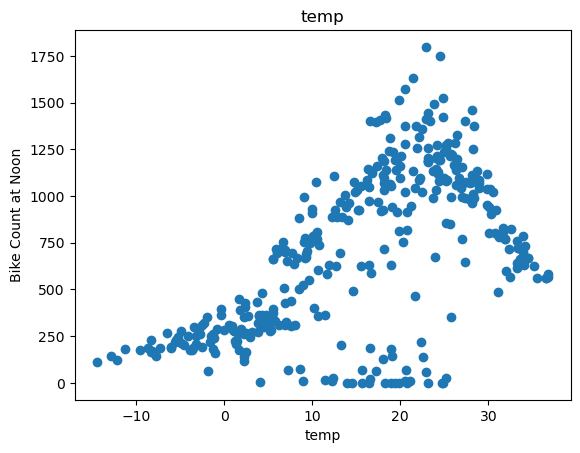

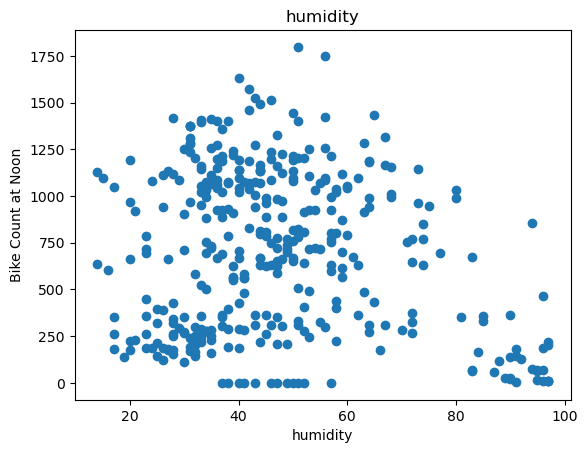

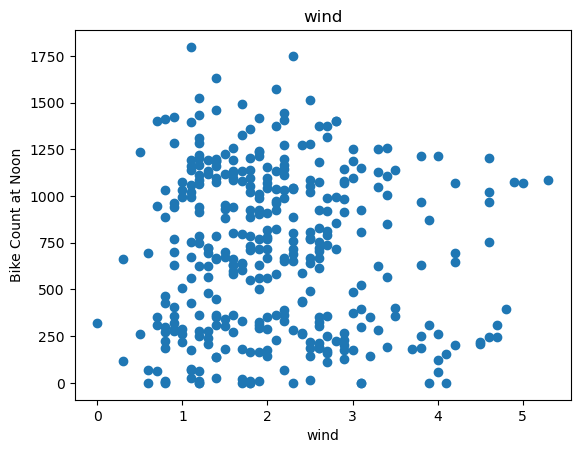

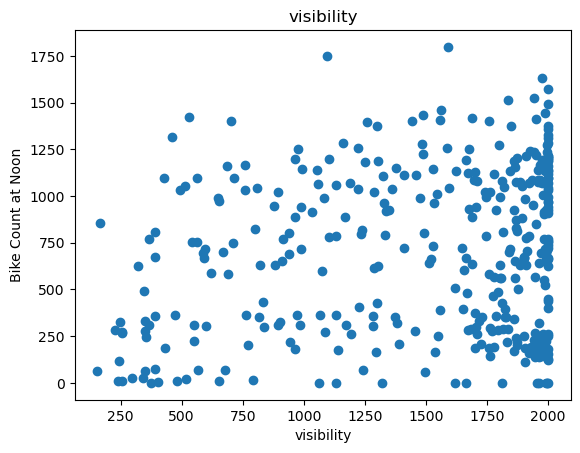

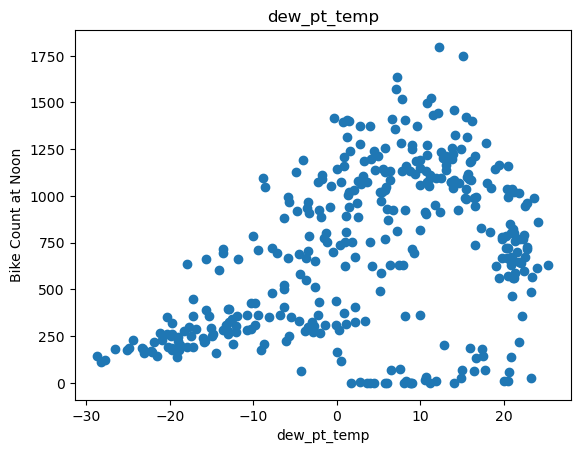

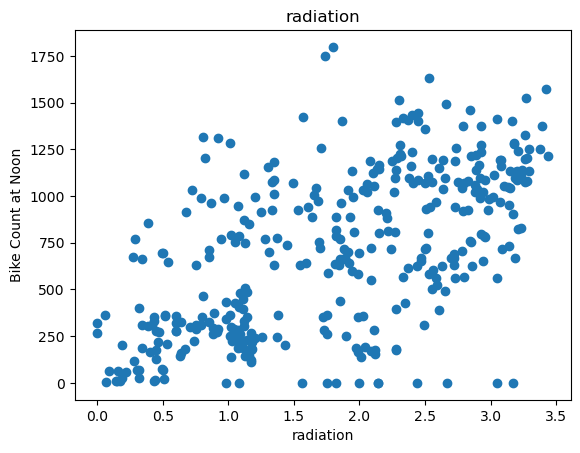

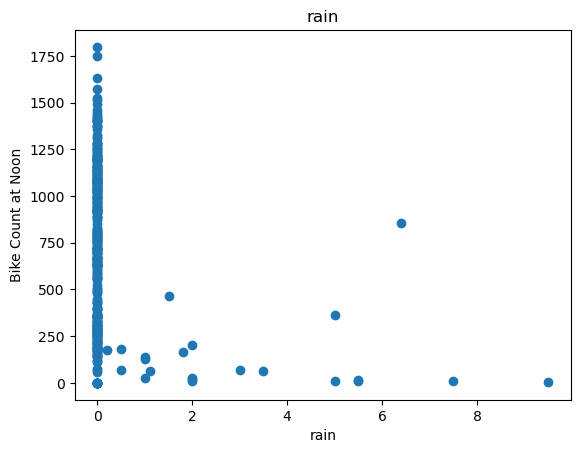

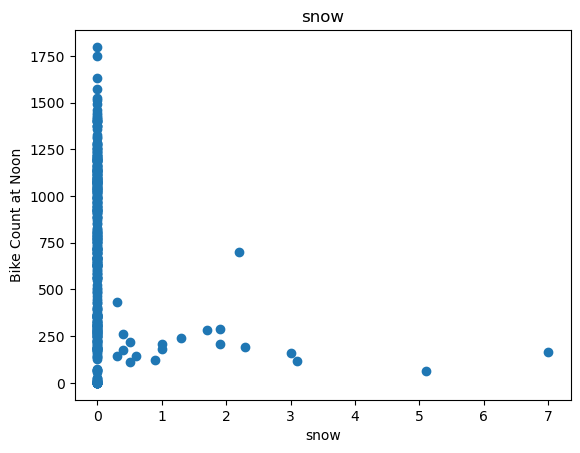

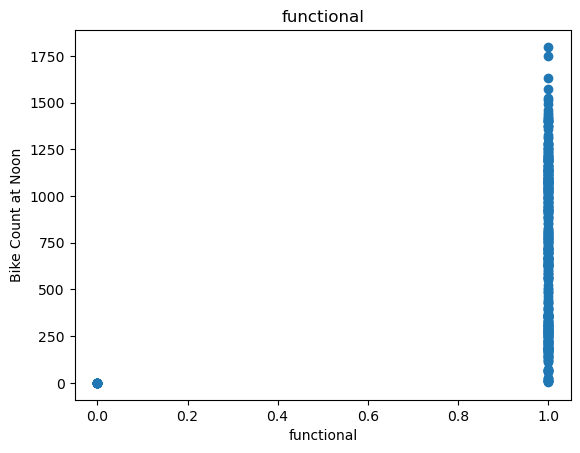

In [165]:
for label in df.columns[1:]:
    plt.scatter(df[label], df["bike_count"])
    plt.title(label)
    plt.ylabel("Bike Count at Noon")
    plt.xlabel(label)
    plt.show()
    
    
    
    

In [166]:
df = df.drop(["wind", "visibility", "functional"], axis=1)

In [167]:
df.head()

,bike_count,temp,humidity,dew_pt_temp,radiation,rain,snow
12,449,1.7,23,-17.2,1.11,0.0,0.0
36,479,4.3,41,-7.8,1.09,0.0,0.0
60,333,5.8,85,3.4,0.43,0.0,0.0
84,393,-0.3,38,-12.9,1.11,0.0,0.0
108,321,-2.3,25,-19.7,0.00,0.0,0.0


In [173]:
# o pio neos tropos gia na xrhsimopoihsoyme ton kwdika

# Χρησιμοποιούμε το .iloc αντί για np.split για να είμαστε 100% συμβατοί με τα Pandas
df_shuffled = df.sample(frac=1, random_state=42)

train, val, test = (
    df_shuffled.iloc[:int(0.6*len(df))], 
    df_shuffled.iloc[int(0.6*len(df)):int(0.8*len(df))], 
    df_shuffled.iloc[int(0.8*len(df)):]
)


In [174]:
# Train/valid/test dataset
train, val, test = np.split(df.sample(frac=1), [int(0.6*len(df)), int(0.8*len(df))]) 


C:\Users\spiro\miniconda3\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [175]:


def get_xy(dataframe, y_label, x_labels=None):
    dataframe = copy.deepcopy(dataframe)
    
    # Απομόνωση του y πάντα σε δισδιάστατη μορφή (N, 1)
    y = dataframe[y_label].values.reshape(-1, 1)
    
    if not x_labels:
        # Αν δεν δώσουμε λίστα, παίρνει όλες τις στήλες εκτός από το y
        X = dataframe[[c for c in dataframe.columns if c != y_label]].values
    else:
        # Αν δώσουμε λίστα, παίρνει μόνο αυτές τις στήλες
        X = dataframe[x_labels].values
        # Δικλείδα ασφαλείας: Αν επιλέξαμε μόνο 1 στήλη, τη μετατρέπει σε 2D (N, 1)
        if len(x_labels) == 1:
            X = X.reshape(-1, 1)
            
    # Ένωση των X (N, features) και y (N, 1) οριζόντια
    data = np.hstack((X, y))
        
    return data, X, y




        


In [176]:
_, X_train_temp, y_train_temp = get_xy(train, "bike_count", x_labels=["temp"])
_, X_val_temp, y_val_temp = get_xy(val, "bike_count", x_labels=["temp"])
_, X_test_temp, y_test_temp = get_xy(test, "bike_count", x_labels=["temp"])

In [178]:


# 1. Δημιουργία και Εκπαίδευση του Simple Linear Regression μοντέλου
temp_reg = LinearRegression()
temp_reg.fit(X_train_temp, y_train_temp)

print("Το μοντέλο Simple Linear Regression εκπαιδεύτηκε επιτυχώς!\n")

# 2. Σωστή εκτύπωση των ενα συντελεστών (Βάρη w) στρογγυλοποιημένων στα 2 δεκαδικά
print("Συντελεστές (Βάρη w για μια στήλη):")
print(np.round(temp_reg.coef_, 2))

# 3. Εκτύπωση της σταθεράς b
print(f"\nΣταθερά (Σφάλμα b): {temp_reg.intercept_[0]:.2f}")


Το μοντέλο Multiple Linear Regression εκπαιδεύτηκε επιτυχώς!

Συντελεστές (Βάρη w για κάθε στήλη):
[[20.63]]

Σταθερά (Σφάλμα b): 346.29


In [179]:
# Υπολογισμός του R² Score με μετατροπή του X_test_temp σε 2D array
r2_score_result = temp_reg.score(X_test_temp.reshape(-1, 1), y_test_temp)

print(f"R² Score του μοντέλου στο Test Set: {r2_score_result:.4f}")


R² Score του μοντέλου στο Test Set: 0.3068


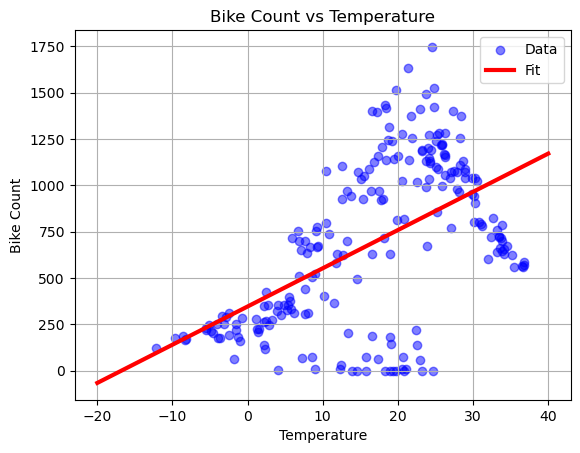

In [180]:
# 1. Παίρνουμε σωστά το X και το y ΜΑΖΙ από το train set
_, X_train_temp, y_train_temp = get_xy(train, y_label="bike_count", x_labels=["temp"])

# 2. Σχεδίαση των πραγματικών δεδομένων (Τώρα τα μεγέθη θα είναι 100% ίδια)
plt.scatter(X_train_temp, y_train_temp, label="Data", color="blue", alpha=0.5)

# 3. Δημιουργία των 100 σημείων για την κόκκινη γραμμή (Fit)
# Μετατρέπουμε το linspace σε πίνακα NumPy με κατάλληλο σχήμα (100, 1)
x = tf.linspace(-20, 40, 100)
x_numpy = np.array(x).reshape(-1, 1)

# 4. Σχεδίαση της κόκκινης γραμμής πρόβλεψης
plt.plot(x_numpy, temp_reg.predict(x_numpy), label="Fit", color="red", linewidth=3)

# 5. Προσθήκη τίτλων και εμφάνιση
plt.title("Bike Count vs Temperature")
plt.xlabel("Temperature")
plt.ylabel("Bike Count")
plt.legend()
plt.grid(True)
plt.show()


In [181]:
# Multiple Linear Regression
# Προσθήκη του .tolist() στο τέλος των στηλών και αλλαγή των ονομάτων σε _all αντί για _temp
x_columns_list = df.columns[1:].tolist()

_, X_train_all, y_train_all = get_xy(train, "bike_count", x_labels=x_columns_list)
_, X_val_all, y_val_all = get_xy(val, "bike_count", x_labels=x_columns_list)
_, X_test_all, y_test_all = get_xy(test, "bike_count", x_labels=x_columns_list)

print("Τα δεδομένα για το Multiple Linear Regression φορτώθηκαν επιτυχώς!")
print(f"Σχήμα X_train_all: {X_train_all.shape}") # Πρέπει να δείχνει έναν δισδιάστατο πίνακα τώρα


Τα δεδομένα για το Multiple Linear Regression φορτώθηκαν επιτυχώς!
Σχήμα X_train_all: (219, 6)


In [182]:
all_reg = LinearRegression ()
all_reg.fit(X_train_all, y_train_all)





,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [183]:
all_reg.score(X_test_all, y_test_all)

0.4784230084755049

In [192]:
def plot_loss(history):
    plt.plot(history.history["loss"], label="loss")
    plt.plot(history.history["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.legend()
    plt.grid(True)
    plt.show()
    

In [184]:
# Regression with Neural Net
temp_normalizer = tf.keras.layers.Normalization(input_shape=(1,), axis=None)
temp_normalizer.adapt(X_train_temp.reshape(-1))

C:\Users\spiro\miniconda3\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [187]:
temp_nn_model = tf.keras.Sequential ([
temp_normalizer,
tf.keras.layers.Dense(1)

    ])

In [189]:
temp_nn_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.1), loss="mean_squared_error")

In [191]:
history = temp_nn_model.fit (
    X_train_temp.reshape(-1), y_train_temp,
    verbose=0,
    epochs=1000,
    validation_data=(X_val_temp, y_val_temp)
    
)  
    


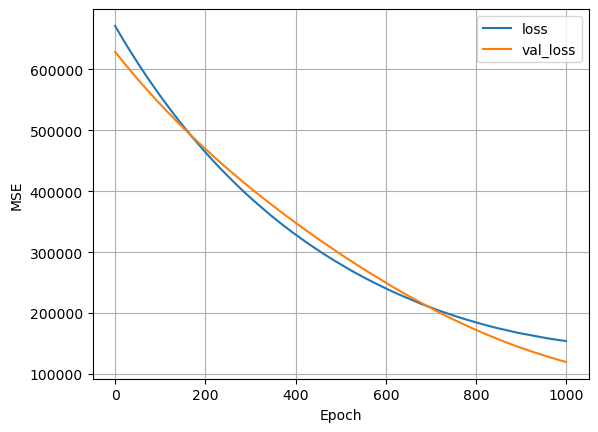

In [193]:
plot_loss(history)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


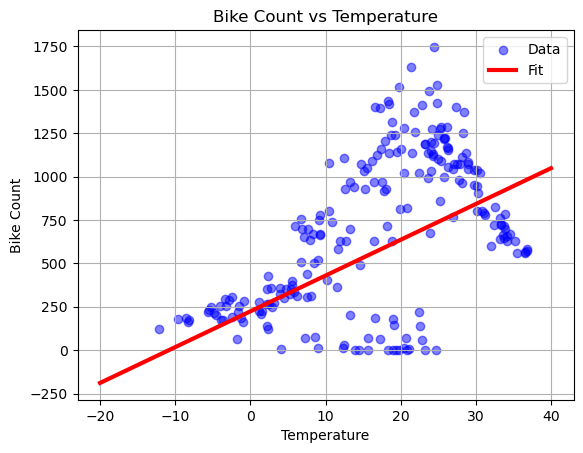

In [194]:
# 1. Παίρνουμε σωστά το X και το y ΜΑΖΙ από το train set
_, X_train_temp, y_train_temp = get_xy(train, y_label="bike_count", x_labels=["temp"])

# 2. Σχεδίαση των πραγματικών δεδομένων (Τώρα τα μεγέθη θα είναι 100% ίδια)
plt.scatter(X_train_temp, y_train_temp, label="Data", color="blue", alpha=0.5)

# 3. Δημιουργία των 100 σημείων για την κόκκινη γραμμή (Fit)
# Μετατρέπουμε το linspace σε πίνακα NumPy με κατάλληλο σχήμα (100, 1)
x = tf.linspace(-20, 40, 100)
x_numpy = np.array(x).reshape(-1, 1)

# 4. Σχεδίαση της κόκκινης γραμμής πρόβλεψης
plt.plot(x_numpy, temp_nn_model.predict(x_numpy), label="Fit", color="red", linewidth=3)

# 5. Προσθήκη τίτλων και εμφάνιση
plt.title("Bike Count vs Temperature")
plt.xlabel("Temperature")
plt.ylabel("Bike Count")
plt.legend()
plt.grid(True)
plt.show()


In [195]:
# 1. Δημιουργία και Εκπαίδευση του Multiple Linear Regression μοντέλου
all_reg = LinearRegression()
all_reg.fit(X_train_all, y_train_all)

print("Το μοντέλο Multiple Linear Regression εκπαιδεύτηκε επιτυχώς!\n")

# 2. Σωστή εκτύπωση των πολλών συντελεστών (Βάρη w) στρογγυλοποιημένων στα 2 δεκαδικά
print("Συντελεστές (Βάρη w για κάθε στήλη):")
print(np.round(all_reg.coef_, 2))

# 3. Εκτύπωση της σταθεράς b
print(f"\nΣταθερά (Σφάλμα b): {all_reg.intercept_[0]:.2f}")

Το μοντέλο Multiple Linear Regression εκπαιδεύτηκε επιτυχώς!

Συντελεστές (Βάρη w για κάθε στήλη):
[[-10.76  -9.29  26.62 159.79 -18.38  -8.23]]

Σταθερά (Σφάλμα b): 902.13


In [212]:
# Neural net
temp_normalizer = tf.keras.layers.Normalization(input_shape=(1,), axis=None)
temp_normalizer.adapt(X_train_temp.reshape(-1))

nn_model = tf.keras.Sequential ([
temp_normalizer,
tf.keras.layers.Dense(32, activation="relu"),
tf.keras.layers.Dense(32, activation="relu"),
tf.keras.layers.Dense(32, activation="relu"),
tf.keras.layers.Dense(1)

    ])
nn_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss="mean_squared_error")

C:\Users\spiro\miniconda3\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [213]:
history = nn_model.fit(
    X_train_temp, y_train_temp,
    validation_data=(X_val_temp, y_val_temp),
    verbose=0, epochs=100
)

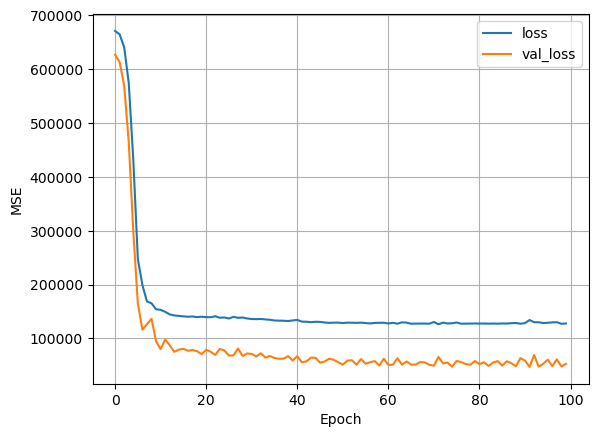

In [214]:
plot_loss(history)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


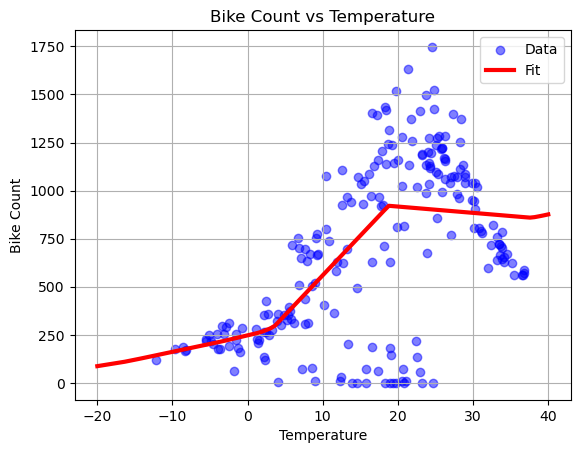

In [215]:
# 1. Παίρνουμε σωστά το X και το y ΜΑΖΙ από το train set
_, X_train_temp, y_train_temp = get_xy(train, y_label="bike_count", x_labels=["temp"])

# 2. Σχεδίαση των πραγματικών δεδομένων (Τώρα τα μεγέθη θα είναι 100% ίδια)
plt.scatter(X_train_temp, y_train_temp, label="Data", color="blue", alpha=0.5)

# 3. Δημιουργία των 100 σημείων για την κόκκινη γραμμή (Fit)
# Μετατρέπουμε το linspace σε πίνακα NumPy με κατάλληλο σχήμα (100, 1)
x = tf.linspace(-20, 40, 100)
x_numpy = np.array(x).reshape(-1, 1)

# 4. Σχεδίαση της κόκκινης γραμμής πρόβλεψης
plt.plot(x_numpy, nn_model.predict(x_numpy), label="Fit", color="red", linewidth=3)

# 5. Προσθήκη τίτλων και εμφάνιση
plt.title("Bike Count vs Temperature")
plt.xlabel("Temperature")
plt.ylabel("Bike Count")
plt.legend()
plt.grid(True)
plt.show()


In [235]:
# Neural net
all_normalizer = tf.keras.layers.Normalization(input_shape=(6,), axis=-1)
all_normalizer.adapt(X_train_all)



C:\Users\spiro\miniconda3\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [236]:


# 1. Σωστός ορισμός του normalizer για 6 χαρακτηριστικά
all_normalizer = tf.keras.layers.Normalization(axis=-1)
all_normalizer.adapt(X_train_all) # Προσαρμογή στα δεδομένα σας

# 2. Ανακατασκευή του μοντέλου
nn_model = tf.keras.Sequential([
    all_normalizer,
    tf.keras.layers.Flatten(), # Εξασφαλίζει ότι τα δεδομένα θα είναι 2D (None, 6)
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1)
])

# 3. Μεταγλώττιση
nn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), 
    loss="mean_squared_error"
)


In [237]:
history = nn_model.fit(
    X_train_all, y_train_all,
    validation_data=(X_val_all, y_val_all),
    verbose=0, epochs=100
)

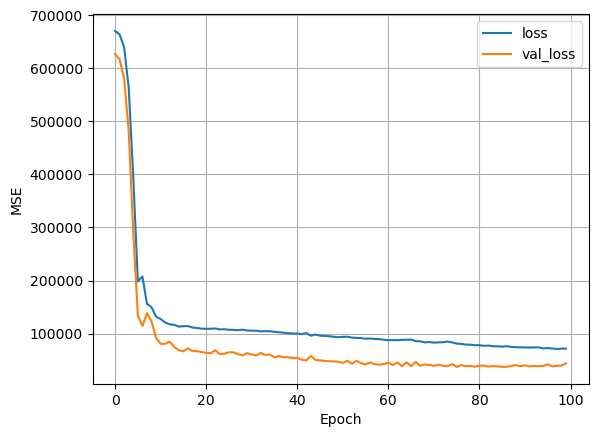

In [238]:
plot_loss(history)

In [239]:
# Calculate the MSE for both linear reg and nn
y_pred_lr = all_reg.predict(X_test_all)
y_pred_nn = nn_model.predict(X_test_all)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


In [240]:
def MSE(y_pred, y_real):
   return (np.square(y_pred - y_real)).mean()
    

In [241]:
MSE(y_pred_lr, y_test_all)

np.float64(100841.14313366334)

In [242]:
MSE(y_pred_nn, y_test_all)

np.float64(66882.73520234214)

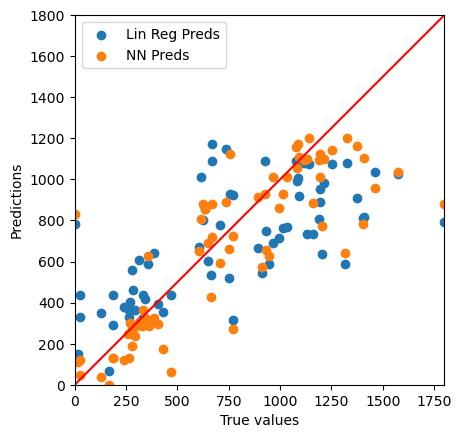

In [248]:
ax = plt.axes(aspect="equal")
plt.scatter(y_test_all, y_pred_lr, label="Lin Reg Preds")
plt.scatter(y_test_all, y_pred_nn, label="NN Preds")
plt.xlabel("True values")
plt.ylabel("Predictions")
lims = (0, 1800)
plt.xlim(lims)
plt.ylim(lims)
plt.legend()
_ = plt.plot(lims, lims, c="red")

